In [2]:
pip install pandas numpy scikit-learn matplotlib

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - ------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\lahar\OneDrive\Desktop\Infotech task1
['Dataset Glossary.txt', 'House_Rent_Dataset.csv']


In [7]:
import os
print(os.listdir())

['Dataset Glossary.txt', 'House_Rent_Dataset.csv']


In [10]:
import pandas as pd
import os

print(os.getcwd())      # shows current folder
print(os.listdir())     # shows files inside folder

c:\Users\lahar\OneDrive\Desktop\Infotech task1
['Dataset Glossary.txt', 'House_Rent_Dataset.csv']


In [13]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Create dataset
data = pd.DataFrame({
    'Size': [1000, 1200, 1500, 1800, 2000],
    'BHK': [2, 2, 3, 3, 4],
    'Bathroom': [1, 2, 2, 3, 3],
    'Rent': [10000, 12000, 18000, 22000, 25000]
})

# Select features
X = data[['Size', 'BHK', 'Bathroom']]
y = data['Rent']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
print("Prediction:", model.predict([[1600, 3, 2]])[0])

Prediction: 20166.666666666675


c:\Users\lahar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training Data:", X_train)
print("Testing Data:", X_test)

Training Data:    Size  BHK  Bathroom
4  2000    4         3
2  1500    3         2
0  1000    2         1
3  1800    3         3
Testing Data:    Size  BHK  Bathroom
1  1200    2         2


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [16]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -4961.504142275837
Coefficients: [  14.87168047  192.33057182 -128.17080894]


In [17]:
y_pred = model.predict(X_test)
print("Predicted Values:", y_pred)

Predicted Values: [13012.83195257]


In [18]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 1025828.564156322
R2 Score: nan


c:\Users\lahar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [19]:
new_house = [[1600, 3, 2]]
prediction = model.predict(new_house)

print("Predicted Rent:", prediction[0])

Predicted Rent: 19153.834714091943


c:\Users\lahar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


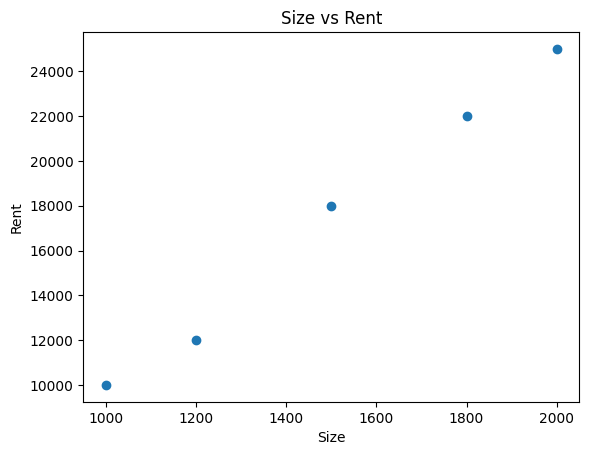

In [20]:
import matplotlib.pyplot as plt

plt.scatter(data['Size'], data['Rent'])
plt.xlabel("Size")
plt.ylabel("Rent")
plt.title("Size vs Rent")
plt.show()

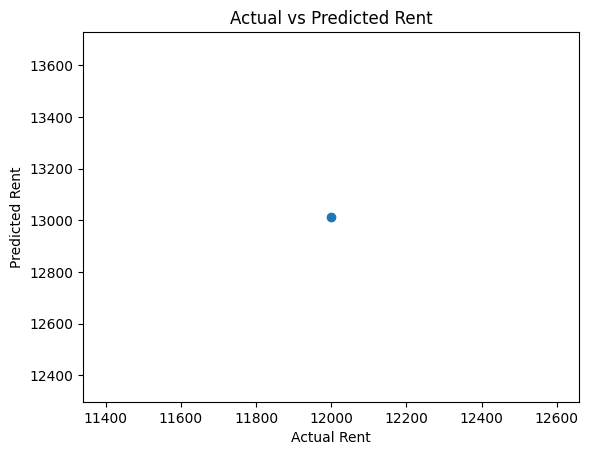

In [21]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")
plt.show()

In [22]:
import joblib

joblib.dump(model, "rent_model.pkl")
print("Model saved")

Model saved


In [23]:
loaded_model = joblib.load("rent_model.pkl")
print("Loaded Model Prediction:", loaded_model.predict([[1400, 2, 2]])[0])

Loaded Model Prediction: 15987.168047425272


c:\Users\lahar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
print("Rent =",
      model.intercept_,
      "+", model.coef_[0], "* Size",
      "+", model.coef_[1], "* BHK",
      "+", model.coef_[2], "* Bathroom")

Rent = -4961.504142275837 + 14.871680474252766 * Size + 192.33057181611602 * BHK + -128.17080894249648 * Bathroom
